In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.6f}'.format)

In [2]:
data = pd.read_csv("UDPLag.csv")

In [3]:
data.shape

(370605, 88)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370605 entries, 0 to 370604
Data columns (total 88 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0                    370605 non-null  int64  
 1   Flow ID                       370605 non-null  object 
 2    Source IP                    370605 non-null  object 
 3    Source Port                  370605 non-null  int64  
 4    Destination IP               370605 non-null  object 
 5    Destination Port             370605 non-null  int64  
 6    Protocol                     370605 non-null  int64  
 7    Timestamp                    370605 non-null  object 
 8    Flow Duration                370605 non-null  int64  
 9    Total Fwd Packets            370605 non-null  int64  
 10   Total Backward Packets       370605 non-null  int64  
 11  Total Length of Fwd Packets   370605 non-null  float64
 12   Total Length of Bwd Packets  370605 non-nul

In [5]:
data.dtypes.value_counts()

float64    45
int64      37
object      6
Name: count, dtype: int64

In [8]:
data.isna().sum()

Unnamed: 0         0
Flow ID            0
 Source IP         0
 Source Port       0
 Destination IP    0
                  ..
 Idle Max          0
 Idle Min          0
SimillarHTTP       0
 Inbound           0
 Label             0
Length: 88, dtype: int64

In [9]:
data.describe()

,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
count,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,...,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000
mean,185302.000000,38359.243650,32650.266985,7.502648,5266594.330635,2.966814,0.331339,200.874106,31.320889,68.622161,...,-3925622.077840,5673.201380,3762.267664,8965.922716,3135.026538,2944175.840121,458258.178301,3295114.402337,2599586.655115,0.989458
std,106984.592594,17813.786844,19081.438104,3.779511,12500774.726713,23.184712,2.459441,690.324235,1980.049015,214.448926,...,64470568.136349,134951.776573,104550.663819,217880.318482,109065.524578,7039896.320944,1684694.212171,7794375.868595,6459172.354096,0.102133
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-1062718975.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92651.000000,23937.000000,16158.000000,6.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,185302.000000,39867.000000,32720.000000,6.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,277953.000000,53812.000000,49211.000000,6.000000,116.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,370604.000000,65532.000000,65535.000000,17.000000,119999992.000000,8456.000000,421.000000,67750.000000,670016.000000,3087.000000,...,1472.000000,18300116.000000,22840639.735979,53761691.000000,14619917.000000,95146794.000000,33338860.024001,95146794.000000,95146794.000000,1.000000


In [10]:
data.columns = data.columns.str.strip()

In [11]:
data = data.drop(columns=['Unnamed: 0','Flow ID','Source IP','Source Port','Destination IP','Destination Port','Protocol'])

In [12]:
data['Label'].value_counts()

Label
UDP-lag    366461
BENIGN       3705
WebDDoS       439
Name: count, dtype: int64

In [13]:
data.select_dtypes(include=['object'])

,Timestamp,SimillarHTTP,Label
0,2018-12-01 13:04:45.928673,0,UDP-lag
1,2018-12-01 13:04:45.928913,0,UDP-lag
2,2018-12-01 13:04:45.928915,0,UDP-lag
3,2018-12-01 13:04:45.929024,0,UDP-lag
4,2018-12-01 13:04:45.929096,0,UDP-lag
...,...,...,...
370600,2018-12-01 13:30:30.740273,0,UDP-lag
370601,2018-12-01 13:30:30.740323,0,UDP-lag
370602,2018-12-01 13:30:30.740374,0,UDP-lag
370603,2018-12-01 13:30:30.740424,0,UDP-lag


In [14]:
data['SimillarHTTP'].value_counts()

SimillarHTTP
0                                                                                                                                       280493
0                                                                                                                                        89846
205.174.165.72/c.php                                                                                                                        89
ocsp.pki.goog/GTSGIAG3                                                                                                                      24
ocsp.digicert.com/                                                                                                                          16
                                                                                                                                         ...  
205.174.165.72/c.php?ip=10.198.133.247                                                                                           

In [15]:
data['SimillarHTTP'] = data['SimillarHTTP'].astype(str)

In [16]:
data['SimillarHTTP'].value_counts()

SimillarHTTP
0                                                                                                                                       370339
205.174.165.72/c.php                                                                                                                        89
ocsp.pki.goog/GTSGIAG3                                                                                                                      24
ocsp.digicert.com/                                                                                                                          16
205.174.165.72null                                                                                                                          10
                                                                                                                                         ...  
205.174.165.72/c.php?ip=10.198.133.247                                                                                           

In [17]:
data["SimilarHTTP_flag"] = (data["SimillarHTTP"] != "0").astype(int)

In [18]:
data["SimilarHTTP_flag"].value_counts()

SimilarHTTP_flag
0    370339
1       266
Name: count, dtype: int64

In [19]:
data = data.drop(columns=['SimillarHTTP'])

<Axes: >

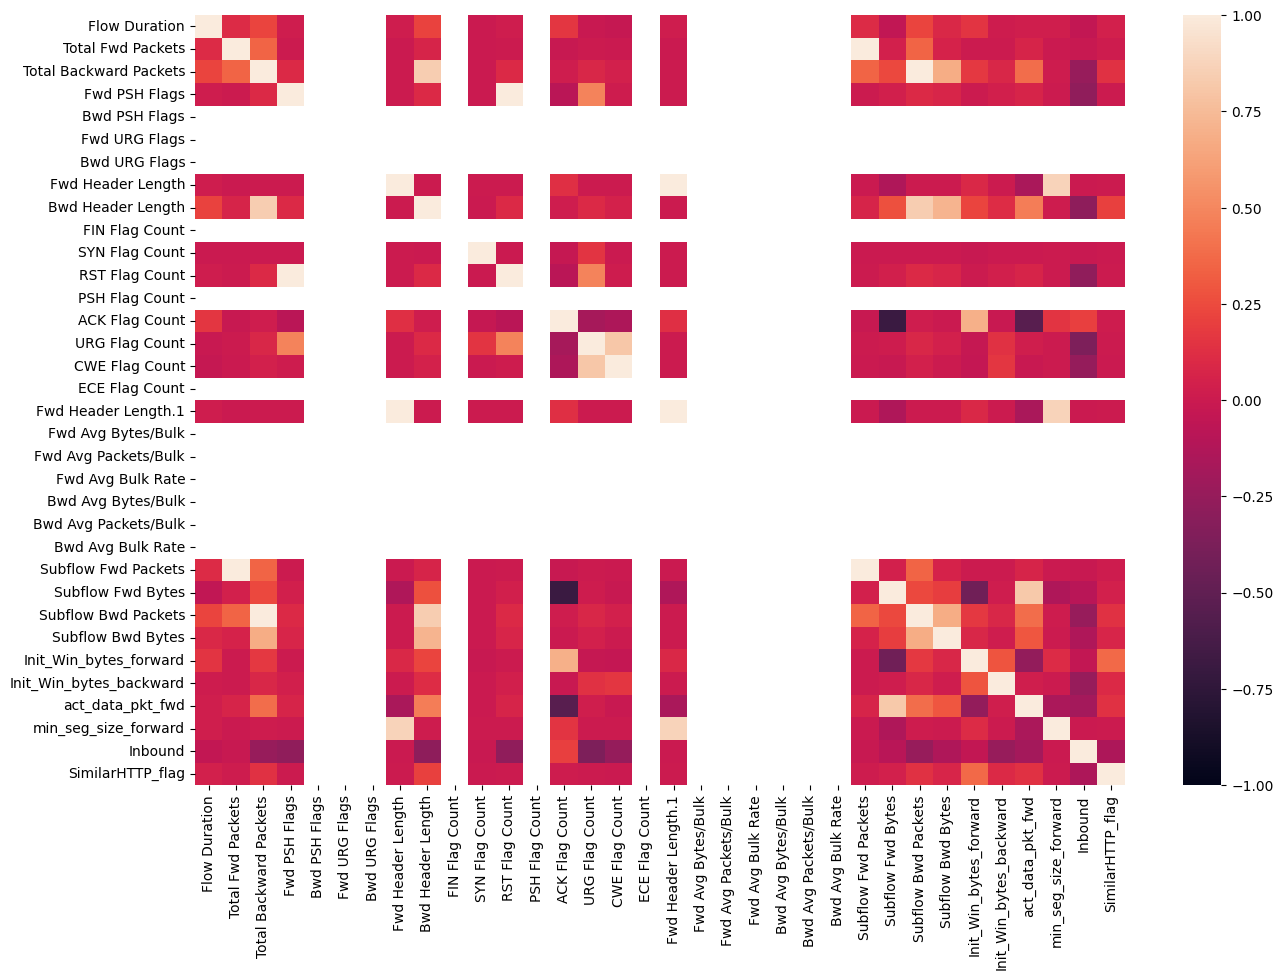

In [20]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.select_dtypes(include=['int64']).corr(),vmax=1,vmin=-1)

In [38]:
data_int = data.select_dtypes(include=['int64'])

<Axes: >

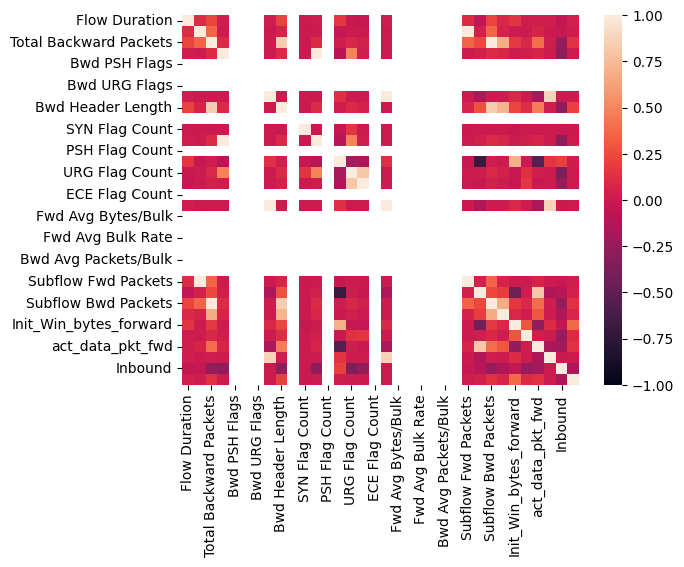

In [39]:
sns.heatmap(data_int.corr(),vmin=-1,vmax=1)

In [40]:
int_cols = [
"Subflow Fwd Packets",
"Subflow Bwd Packets",
"Init_Win_bytes_forward",
"Init_Win_bytes_backward",
"Fwd Header Length.1",
"RST Flag Count",
"URG Flag Count",
"CWE Flag Count",
"ECE Flag Count",
"Bwd PSH Flags",
"Fwd URG Flags",
"Bwd URG Flags",
"Fwd Avg Packets/Bulk",
"Bwd Avg Packets/Bulk",
"Bwd Header Length",
"act_data_pkt_fwd",
"FIN Flag Count",
"PSH Flag Count",
"Fwd Avg Bytes/Bulk",
"Fwd Avg Bulk Rate",
"Bwd Avg Bytes/Bulk",
"Bwd Avg Bulk Rate"]

In [41]:
data_int = data_int.drop(columns=int_cols) 

In [42]:
data_int.corr()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd PSH Flags,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Fwd Bytes,Subflow Bwd Bytes,min_seg_size_forward,Inbound,SimilarHTTP_flag
Flow Duration,1.000000,0.103071,0.224167,0.018519,0.021520,-0.004837,0.161586,-0.051519,0.087720,0.024747,-0.045338,0.046693
Total Fwd Packets,0.103071,1.000000,0.350808,0.007527,-0.006065,-0.000490,-0.016031,0.042463,0.057581,-0.005056,-0.015993,0.013966
Total Backward Packets,0.224167,0.350808,1.000000,0.097756,0.007161,-0.000404,0.015846,0.238714,0.674752,0.008203,-0.244623,0.136780
Fwd PSH Flags,0.018519,0.007527,0.097756,1.000000,0.001822,-0.000394,-0.084304,0.035012,0.073920,0.002087,-0.278866,0.002024
Fwd Header Length,0.021520,-0.006065,0.007161,0.001822,1.000000,0.000611,0.130720,-0.140118,0.000841,0.872941,-0.004345,0.001425
SYN Flag Count,-0.004837,-0.000490,-0.000404,-0.000394,0.000611,1.000000,-0.028280,-0.003042,-0.000150,0.000700,-0.010302,-0.000308
ACK Flag Count,0.161586,-0.016031,0.015846,-0.084304,0.130720,-0.028280,1.000000,-0.689242,-0.004479,0.149746,0.199938,0.010320
Subflow Fwd Bytes,-0.051519,0.042463,0.238714,0.035012,-0.140118,-0.003042,-0.689242,1.000000,0.190335,-0.137581,-0.091997,0.043504
Subflow Bwd Bytes,0.087720,0.057581,0.674752,0.073920,0.000841,-0.000150,-0.004479,0.190335,1.000000,0.000963,-0.140390,0.076604
min_seg_size_forward,0.024747,-0.005056,0.008203,0.002087,0.872941,0.000700,0.149746,-0.137581,0.000963,1.000000,-0.004543,0.001632


<Axes: >

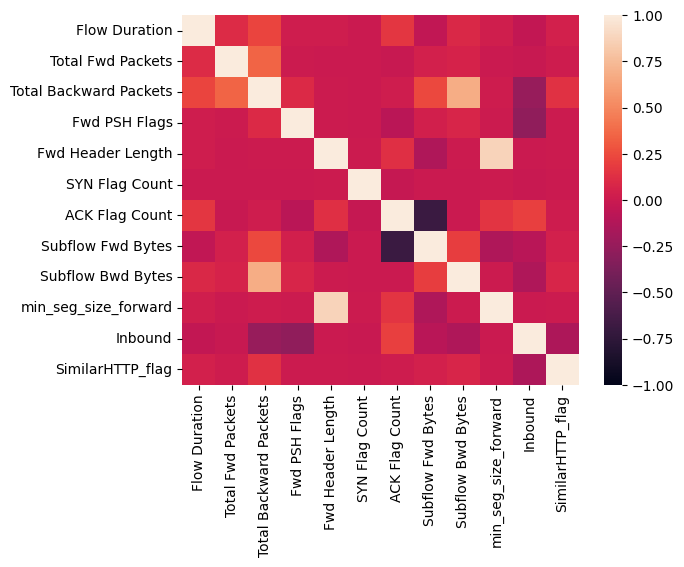

In [43]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [44]:
data_float = data.select_dtypes(include=['float64'])

<Axes: >

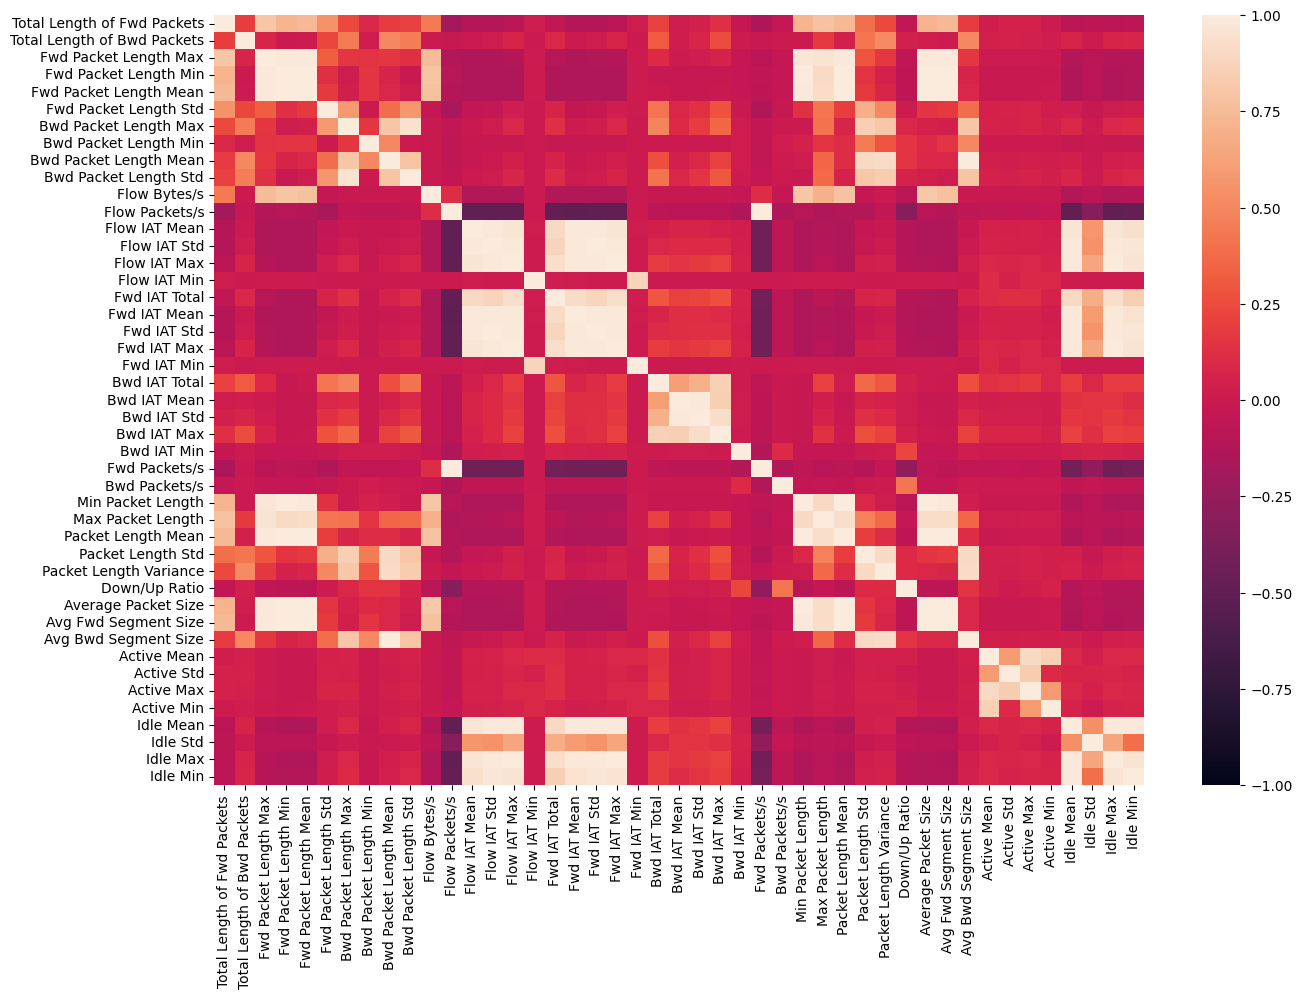

In [47]:
plt.figure(figsize=(15,10))
sns.heatmap(data_float.corr(),vmin=-1,vmax=1)

In [48]:
float_cols = [
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Packet Length Variance",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Avg Fwd Segment Size",
    "Avg Bwd Segment Size",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Std",
    "Idle Max",
    "Idle Min"
]

In [49]:
data_float = data_float.drop(columns=float_cols)

<Axes: >

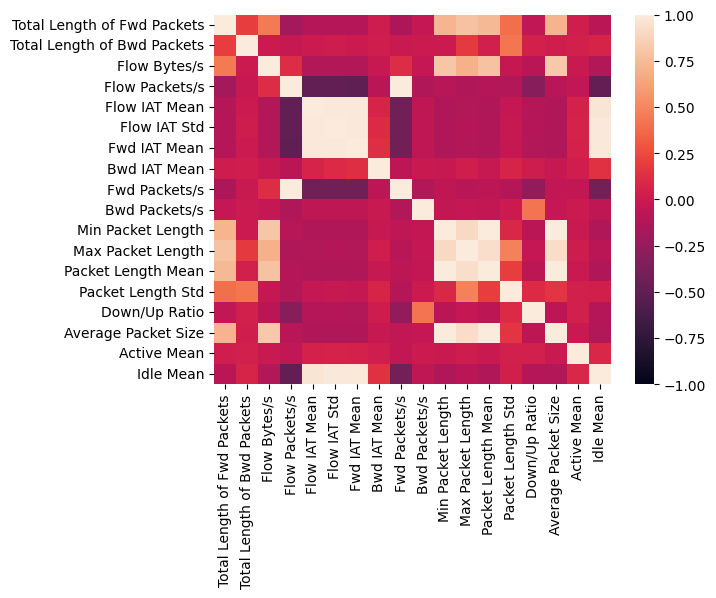

In [50]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [51]:
float_columns, int_columns, obj_columns = list(np.array(data_float.columns)), list(np.array(data_int.columns)), list(np.array(data.select_dtypes(include=['object']).columns))

In [53]:
final_cols = float_columns + int_columns + obj_columns

In [57]:
processeddata = data[final_cols].copy()

<Axes: >

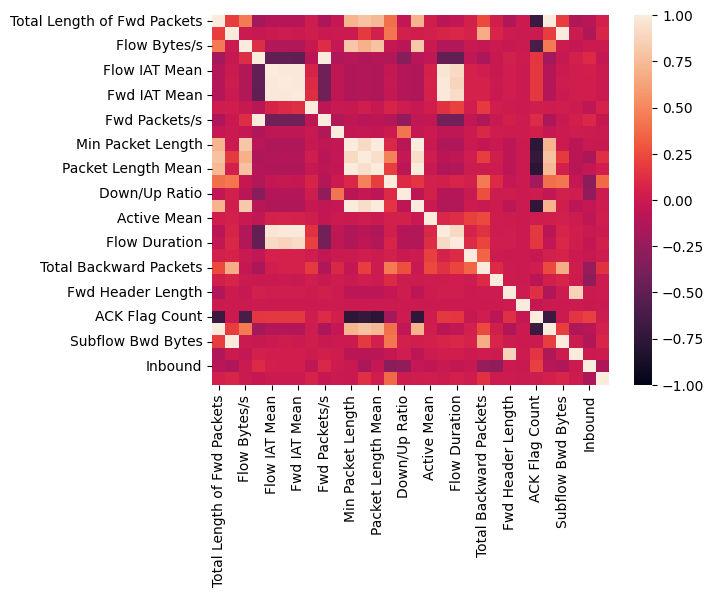

In [60]:
sns.heatmap(processeddata.select_dtypes(include=['int64','float64']).corr(),vmax=1,vmin=-1)

In [62]:
processeddata.isna().sum()

Total Length of Fwd Packets        0
Total Length of Bwd Packets        0
Flow Bytes/s                   36132
Flow Packets/s                     0
Flow IAT Mean                      0
Flow IAT Std                       0
Fwd IAT Mean                       0
Bwd IAT Mean                       0
Fwd Packets/s                      0
Bwd Packets/s                      0
Min Packet Length                  0
Max Packet Length                  0
Packet Length Mean                 0
Packet Length Std                  0
Down/Up Ratio                      0
Average Packet Size                0
Active Mean                        0
Idle Mean                          0
Flow Duration                      0
Total Fwd Packets                  0
Total Backward Packets             0
Fwd PSH Flags                      0
Fwd Header Length                  0
SYN Flag Count                     0
ACK Flag Count                     0
Subflow Fwd Bytes                  0
Subflow Bwd Bytes                  0
m

In [63]:
processeddata["Flow Bytes/s"].fillna(0, inplace=True)

In [64]:
processeddata.isna().sum()

Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Fwd IAT Mean                   0
Bwd IAT Mean                   0
Fwd Packets/s                  0
Bwd Packets/s                  0
Min Packet Length              0
Max Packet Length              0
Packet Length Mean             0
Packet Length Std              0
Down/Up Ratio                  0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Fwd PSH Flags                  0
Fwd Header Length              0
SYN Flag Count                 0
ACK Flag Count                 0
Subflow Fwd Bytes              0
Subflow Bwd Bytes              0
min_seg_size_forward           0
Inbound                        0
SimilarHTTP_flag               0
Timestamp 

In [67]:
processeddata.describe()

,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Packets/s,Bwd Packets/s,...,Total Backward Packets,Fwd PSH Flags,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Fwd Bytes,Subflow Bwd Bytes,min_seg_size_forward,Inbound,SimilarHTTP_flag
count,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,...,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000,370605.000000
mean,200.874106,31.320889,48312693.328467,954518.699407,1021205.768133,1619773.868391,1101585.788290,37924.342080,952550.723278,1967.976129,...,0.331339,0.001174,-9147349.083061,0.000132,0.858116,200.874106,31.320889,-3925622.077840,0.989458,0.000718
std,690.324235,1980.049015,192841326.299704,967626.114366,2403592.346563,3842401.008376,2548953.411369,540940.765393,969258.261897,14402.663606,...,2.459441,0.034240,172093288.074860,0.011498,0.348932,690.324235,1980.049015,64470568.136349,0.102133,0.026781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-21254379500.000000,0.000000,0.000000,0.000000,0.000000,-1062718975.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.322807,1.000000,0.000000,1.000000,0.000000,0.274296,0.000000,...,0.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,20.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,666666.666667,1.000000,0.000000,1.000000,0.000000,666666.666667,0.000000,...,0.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,20.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,2000000.000000,51.000000,63.508530,50.000000,0.000000,2000000.000000,0.000000,...,0.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,20.000000,1.000000,0.000000
max,67750.000000,670016.000000,2944000000.000000,3000000.000000,15914398.666667,35961975.762510,23962226.666667,23962148.333333,3000000.000000,2000000.000000,...,421.000000,1.000000,7192.000000,1.000000,1.000000,67750.000000,670016.000000,1472.000000,1.000000,1.000000


In [70]:
processeddata.replace([np.inf, -np.inf], 0, inplace=True)

In [72]:
processeddata['Timestamp']

0         2018-12-01 13:04:45.928673
1         2018-12-01 13:04:45.928913
2         2018-12-01 13:04:45.928915
3         2018-12-01 13:04:45.929024
4         2018-12-01 13:04:45.929096
                     ...            
370600    2018-12-01 13:30:30.740273
370601    2018-12-01 13:30:30.740323
370602    2018-12-01 13:30:30.740374
370603    2018-12-01 13:30:30.740424
370604    2018-12-01 13:30:30.740425
Name: Timestamp, Length: 370605, dtype: object

In [73]:
processeddata["Timestamp"] = pd.to_datetime(processeddata["Timestamp"])

In [74]:
processeddata["Timestamp"] = processeddata["Timestamp"].dt.strftime("%y-%m-%d %H:%M:%S")

In [77]:
processeddata["Timestamp"].dtypes

dtype('O')

In [78]:
processeddata.set_index("Timestamp",inplace=True)

In [79]:
processeddata

,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Packets/s,Bwd Packets/s,...,Fwd PSH Flags,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Fwd Bytes,Subflow Bwd Bytes,min_seg_size_forward,Inbound,SimilarHTTP_flag,Label
Timestamp,,,,,,,,,,,,,,,,,,,,,
18-12-01 13:04:45,766.000000,0.000000,766000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,766,0,-1,1,0,UDP-lag
18-12-01 13:04:45,778.000000,0.000000,778000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,778,0,-1,1,0,UDP-lag
18-12-01 13:04:45,750.000000,0.000000,375000000.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,-2,0,0,750,0,-1,1,0,UDP-lag
18-12-01 13:04:45,738.000000,0.000000,369000000.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,-2,0,0,738,0,-1,1,0,UDP-lag
18-12-01 13:04:45,750.000000,0.000000,750000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,750,0,-1,1,0,UDP-lag
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18-12-01 13:30:30,0.000000,0.000000,0.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag
18-12-01 13:30:30,0.000000,0.000000,0.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag
18-12-01 13:30:30,0.000000,0.000000,0.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag


In [80]:
processeddata.to_csv("Processed_UDPLag.csv",index=True)

In [84]:
processeddata.shape

(370605, 31)

In [87]:
processeddata

,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Packets/s,Bwd Packets/s,...,Fwd PSH Flags,Fwd Header Length,SYN Flag Count,ACK Flag Count,Subflow Fwd Bytes,Subflow Bwd Bytes,min_seg_size_forward,Inbound,SimilarHTTP_flag,Label
Timestamp,,,,,,,,,,,,,,,,,,,,,
18-12-01 13:04:45,766.000000,0.000000,766000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,766,0,-1,1,0,UDP-lag
18-12-01 13:04:45,778.000000,0.000000,778000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,778,0,-1,1,0,UDP-lag
18-12-01 13:04:45,750.000000,0.000000,375000000.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,-2,0,0,750,0,-1,1,0,UDP-lag
18-12-01 13:04:45,738.000000,0.000000,369000000.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,-2,0,0,738,0,-1,1,0,UDP-lag
18-12-01 13:04:45,750.000000,0.000000,750000000.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,-2,0,0,750,0,-1,1,0,UDP-lag
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18-12-01 13:30:30,0.000000,0.000000,0.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag
18-12-01 13:30:30,0.000000,0.000000,0.000000,2000000.000000,1.000000,0.000000,1.000000,0.000000,2000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag
18-12-01 13:30:30,0.000000,0.000000,0.000000,1000000.000000,2.000000,0.000000,2.000000,0.000000,1000000.000000,0.000000,...,0,40,0,1,0,0,20,1,0,UDP-lag
